# 1-1 수업 내용

- Scikit-learn (싸이킷런)
  - 싸이킷런 소개
  - 싸이킷런으로 표준화
  - 싸이킷런으로 학습한 모델 평가하기

# 9. Scikit-learn 이란?
- 머신러닝 Library가 정말 많지만, 머신러닝 모델을 다루는 대표적인 Library는 다음과같습니다.
  - 1. Scikit-Learn : 머신러닝 대표 라이브러리
  - 2. TensorFlow : 머신러닝 중 딥러닝에 특화된 라이브러리
  - 3. PyTorch : 머신러닝 중 딥러닝에 특화된 라이브러리 (코드 간결성이 더 높음)


<br/>

- 머신러닝 모델은 선형회귀, 로지스틱회귀, 클러스터링, 신경망 등 많거든요.
- 딥러닝은 신경망(Neural Network, 줄여서 NN)을 수십 층으로 딥~ 하게 만든 모델을 의미합니다. (몇 층인지 기준은 없어요.)
- 다시 말하면.. 싸이킷 런은 머신러닝 Library / PyTorch는 딥러닝 Library 입니다.

# 10. Scikit-learn 기본 코드 이해 (선형회귀, 로지스틱회귀)

- 싸이킷런의 Hello world인 선형회귀 모델을 써봅시다.
- 싸이킷 런의 입력 데이터는 2차원 행렬로 입력 받습니다.
- 따라서 입력데이터 X를 2차원 행렬로 변경합니다.
  - reshape(n, 1) : 세로 n x 가로 1 사이즈로 행렬 형태 변경
  - n을 소스코드에서는 -1로 표현합니다.

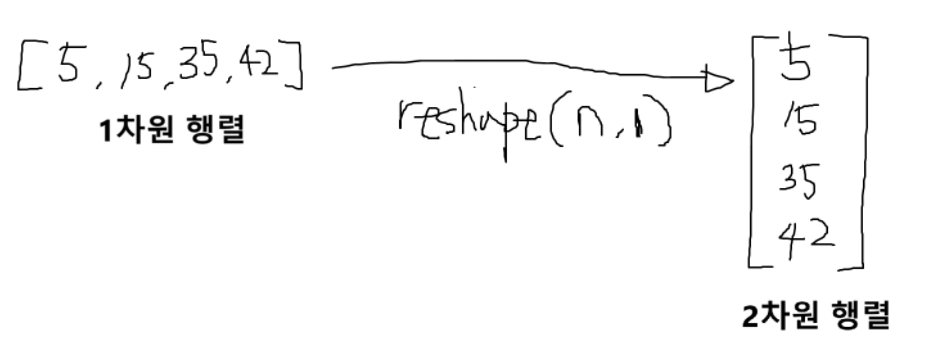

- Library 를 쓰니까, 저번에 직접 구현했던 것 보다 코드가 확실히 간결합니다.

In [7]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


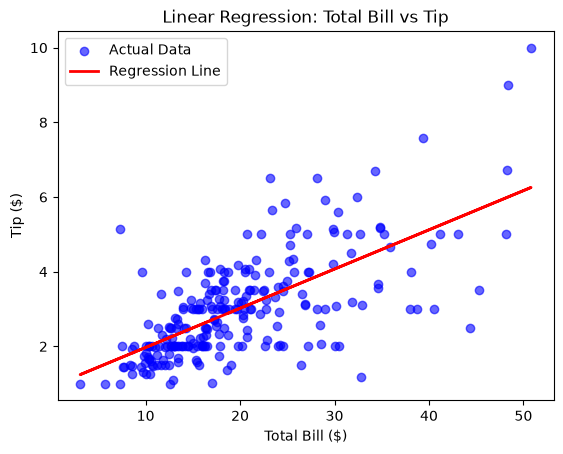

In [8]:

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. 데이터 불러오기
tips = sns.load_dataset("tips")
X = tips["total_bill"].values.reshape(-1, 1)  # 2차원으로 변환, -1 은 'n' 이라는뜻 입니다.
y = tips["tip"].values

# 모델 생성 및 학습
model = LinearRegression()
model.fit(X,y) # X(total_bill), y(tip)


# 예측
y_hat = model.predict(X)

# 시각화
plt.scatter(X, y, color='blue', alpha=0.6, label='Actual Data')
plt.plot(X, y_hat, color='red', linewidth=2, label='Regression Line')

plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.title("Linear Regression: Total Bill vs Tip")
plt.legend()
plt.show()

- 이번엔 로지스틱 회귀입니다
- 저번에 직접 짰던 코드를 Library를 쓴 코드로 바꿔보겠습니다
- 특이한 점은 model.predict_proba( ) 호출 시 탈락확률과 합격확률이 동시에 함께 반환됩니다.
  - 예를들면 f(2시간) = [탈락확률 30%, 합격확률 70%] 이렇게요.
  - 차트는 합격확률만 그리기 위해 "합격확률"만 추출해서 선으로 그렸습니다.

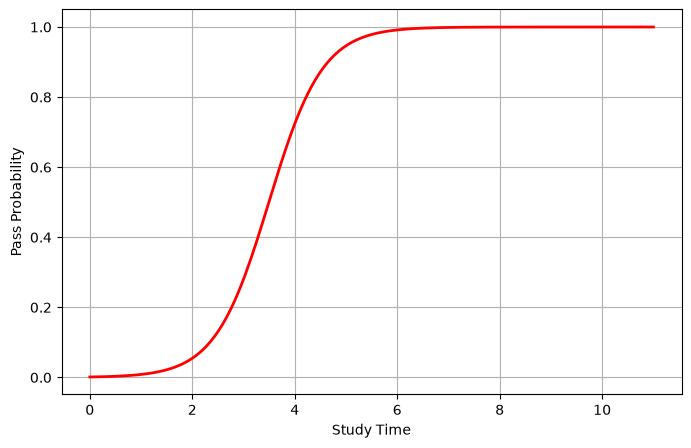

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# 공부 시간 (입력값)
X = np.array([1,2,3,4,5,6,2,3,4,5,6,7,1,2,3,4,5,6,7,8,2,3,4,5,6,7,8,9,10]).reshape(-1, 1)

# 합격 여부 (출력값)
y = np.array([0,0,0,1,1,1,0,0,1,1,1,1,0,0,0,1,1,1,1,1,0,0,1,1,1,1,1,1,1])

model = LogisticRegression()
model.fit(X,y)

X_new = np.linspace(0,11,200).reshape(-1,1) # 0~11시간까지 세밀하게

y_hat = model.predict_proba(X_new) # [탈락확률, 합격확률]
y_hat = y_hat[:,1] # 합격 확률만 추출

plt.figure(figsize=(8, 5))
plt.plot(X_new, y_hat, color='red', linewidth=2)
plt.xlabel("Study Time")
plt.ylabel("Pass Probability")
plt.grid(True)
print()

# 11. 표준화 (전처리)의 필요성
- 데이터를 평균 0, 표준편차 1 형태로 바꾸는 전처리 입니다.

### 전처리 작업을 하는 첫 번째 이유
- 아래와 같은 데이터가 있습니다.
  - 변수 1 : 키 160 ~ 190 cm 범위
  - 변수 2 : 손톱 길이 0.5cm ~ 1.5cm 범위
- 위 원본값을 그대로 학습하면 키 때문에 손톱 데이터가 묻혀요.
- 그래서 아래와 같이 바꿔주면 학습 오작동을 막을 수 있습니다.
  - 전처리 후 변수 1 : 키 0 ~ 1 범위
  - 전처리 후 변수 2 : 손톱 길이 0 ~ 1 범위

### 전처리 작업을 하는 두 번째 이유
- 표준편차 1이 되도록 데이터를 조율 하는 이유입니다.
  - 값 자체만 보면 다른 값과 비교가 안된 원본 값 그대로입니다.
  - 평균에서 얼만큼 벗어난 값인지 수치로 변환하면, 상대적인 값을 확인할 수 있습니다.
  - 예시
    - 원본 값 : [32점, 99점, 15점, 38점, 39502점]
    - 전처리 후 : [하위 2%, 상위 44%, 하위1%, 하위 2.3%, 상위 0.1%]
  - 전처리 후 데이터로 학습하면, GD 학습이 더 잘됩니다.

### 꼭 평균 0, 표준편차 1로 학습해야하나요?
- 아니요. 별 이유없으면 표준화(평균0, 표준편차1)로 하구요.
- 수학 계산상 더 학습이 잘되는 좋은 평균과 표준편차값이 발견되면 다른 값으로 합니다.
- 모델마다 정규화를 어떤 평균값과 어떤 표준편차 값으로 하는지 차이가 있습니다.
  - 입력 데이터에 따라서 AI 학자들이 값을 결정하곤 합니다.

### 정규화와 표준화 차이가 뭔가요?
- 정규화는 값의 범위를 조율하는 행동 자체를 말합니다.
- 표준화는 "평균 0, 표준편차 1"로 정규화 하는 것을 말합니다.
  - 표준화는 정규화 행동 중 하나입니다.


# 12. 표준화 구현하기
- 표준화는 StandardScaler 라는 클래스가 싸이킷런에 준비되어있습니다.
  - 표준화 하는 변환 수식이 있지만 생략합니다~!

- 표준화를 통해 원본 데이터의 특성은 최대한 가져가면서, 학습이 더 잘되도록 값이 변경되는 것입니다.

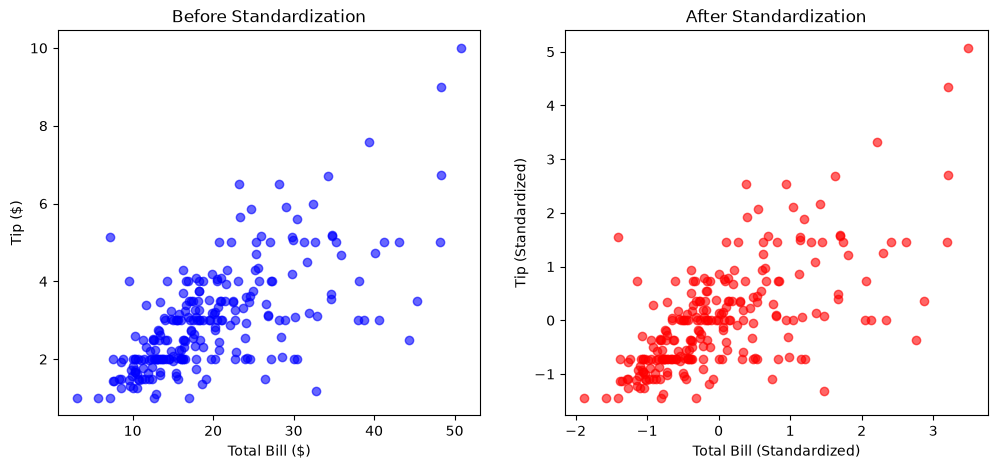

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

tips = sns.load_dataset("tips")

X = tips["total_bill"].values.reshape(-1, 1)  # 2차원으로 변환 (n, 1)
y = tips["tip"].values.reshape(-1, 1)

# 표준화를 해주는 객체만 생성
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# 표준화 하기
scaler_X.fit(X)
scaler_y.fit(y)
X_std = scaler_X.transform(X)
y_std = scaler_y.transform(y)


# sub plot (1 x 2로 2개의 차트로 출력 준비)
fig, axes = plt.subplots(1,2,figsize=(12,5))

# 왼쪽 차트 (원본)
axes[0].scatter(X, y, color='blue', alpha=0.6)
axes[0].set_title("Before Standardization")
axes[0].set_xlabel("Total Bill ($)")
axes[0].set_ylabel("Tip ($)")

# 오른쪽 차트 (표준화 이후)
axes[1].scatter(X_std, y_std, color='red', alpha=0.6)
axes[1].set_title("After Standardization")
axes[1].set_xlabel("Total Bill (Standardized)")
axes[1].set_ylabel("Tip (Standardized)")
print()

# 13. 표준화한 데이터로 선형회귀하기
- 우리 목적은 다음과 같습니다.
  1. 데이터를 표준화 한 후에 학습합시다.
  2. 이후 예측을 해봅시다.

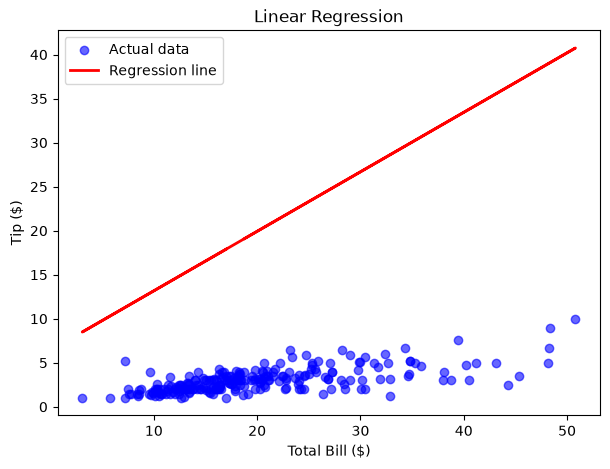

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

tips = sns.load_dataset("tips")

X = tips["total_bill"].values.reshape(-1, 1)
y = tips["tip"].values.reshape(-1, 1)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

scaler_X.fit(X) # fit : 평균과 표준편차 계산하여 내부 변수에 저장해둠
scaler_y.fit(y)
X_std = scaler_X.transform(X) # 변환 (fit을 해야 변환 가능)
y_std = scaler_y.transform(y)

# 선형회귀 모델 학습
model = LinearRegression()
model.fit(X_std, y_std)

# 예측 #표준화된 예측값 : y_hat_std, 0~1 사이의 값
y_hat_std = model.predict(X_std)


# 예측 후 원본값으로 복원
y_hat = scaler_X.inverse_transform(y_hat_std)

# 시각화
plt.figure(figsize=(7,5))
plt.scatter(X, y, color='blue', alpha=0.6, label='Actual data')
plt.plot(X, y_hat, color='red', linewidth=2, label='Regression line')
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.title("Linear Regression")
plt.legend()
plt.show()

- 이제 예측을 해봅시다.
- $50 어치 식사한 손님이 어느 정도 TIP을 낼지 예측해봅시다.
- 표준화를 한 데이터로 만든 모델이므로, 예측할때도 입력 데이터를 표준화 한 후 입력해야한다는 것을 잊지마세요.

In [19]:
new_bill = [[50]]
new_bill_std = scaler_X.transform(new_bill) # 표준화

# 예측하기
pred_tip_std = model.predict(new_bill_std) # 모델 예측 전, 입력 데이터 표준화 필수!!

# 예측값은 평균 0, 표준편차 1 에 맞춘 값이 나왔음. 다시 원상복구
pred_tip = scaler_y.inverse_transform(pred_tip_std)
# 결과 출력
print(f'$50 식사한 손님의 예상 TIP : {pred_tip}')

$50 식사한 손님의 예상 TIP : [[6.17149548]]


# 14. 모델평가하기
- 선형회귀를 생각해보면 y = ax + b 에서, MSE가 가장 낮은 a, b 를 찾는 노력을 해왔습니다.
- 이렇게 완성된 선형회귀 모델이 **처음보는 데이터에 얼마나 예측을 잘하는지?** 평가를 하는 여러가지 방법이 있습니다.

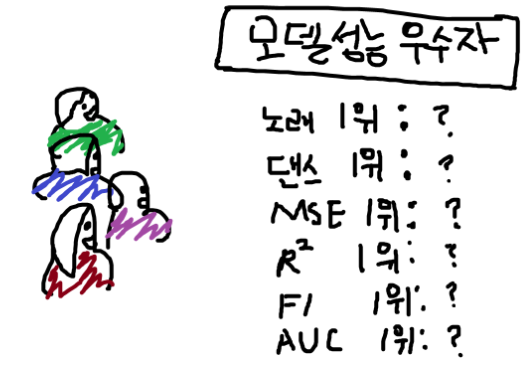

### 모델을 평가하는 이유
- 모델 평가하는 이유는 단순히, 어떤 모델이 더 좋은 모델인가? 를 가리기 위함이 아닙니다.
- 학습 도중에 중간 평가를 하여, 학습을 조율하기 위함입니다. (더 나은 학습을 위해)
  - 예시)
    - 학원 6개 다니면서 학습중인 우리아이는 "4세 고시" 평가 이후에 학원을 2개 더 늘리기로 했습니다~!

### 평가를 위해 데이터를 나누는 방법

- 우리 실습에서는 데이터셋을 몽땅 학습용으로 사용했습니다.
- 평가를 하려면, 학습에 사용하지 않은 데이터로 평가를 해야합니다.
- 일반적인 AI 학습에서는 전체 데이터를 3개의 데이터로 나누는 것이 일반적입니다.
  - **Train Set**
    - 학습용 데이터로 80% 정도 사용합니다.
  - **Validation Set**
    - 검증용 데이터, 학습 중간 중간 평가를 하여 학습 방법을 조율합니다.
    - Validation Set 결과로 학습률(lr.. 점프거리)를 조율하거나 학습을 중단하기도 합니다.
    - 예시
      - '4세 고시' 결과 진도를 더 빼기로 했습니다.
      - 오은영 박사님 검사 결과 학원을 전부 그만두기로 했습니다.
  - **Test Set**
    - 처음보는 데이터로 모델을 평가합니다. (수능점수)

### 싸이킷 런으로 데이터 나누기
- 선형회귀에서는 Validation Set 까지 필요하진 않습니다.
  - 나중에 신경망 모델 에서 필요하긴합니다.
- 간단히 싸이킷 런으로 Train Set과 Test Set을 분리하는 방법을 알아 봅시다.
  - 싸이킷런의 **train_test_split** 함수를 사용합니다.

In [21]:
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

tips = sns.load_dataset("tips")
X = tips["total_bill"].values
y = tips["tip"].values

print(f'원본 개수 : {X.size}개')

# 데이터를 2개로 분리
# X_train, Y_train = 0.8 (80%)
# X_test, Y_test = 0.2 (20%)
# 랜덤으로 섞어줌
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



print()
print(f'[분할 후] Train 데이터 수 : {X_train.size}개')
print(f'[분할 후] Test 데이터 수 : {X_test.size}개')


원본 개수 : 244개

[분할 후] Train 데이터 수 : 195개
[분할 후] Test 데이터 수 : 49개


- 나중을 위해서 한번 3개로 분리를 해봅시다.
- Train = 80%, Validation = 10%, Test = 10%

In [20]:
import seaborn as sns
from sklearn.model_selection import train_test_split

tips = sns.load_dataset("tips")
X = tips["total_bill"].values
y = tips["tip"].values

print(f'원본 개수 : {X.size}개')

# 1차 분할 : Train (80%), 임시 나머지 (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.2,random_state=42)

# 2차 분할 : Validation (10%), Test (10%)
# 전체의 20% 중 절반(=0.5)씩 나눠서 10%, 10%
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state=42)

# 개수 출력
print()
print(f'[분할 후] Train 데이터 수 : {X_train.size}개 (약 80%)')
print(f'[분할 후] Validation 데이터 수 : {X_val.size}개 (약 10%)')
print(f'[분할 후] Test 데이터 수 : {X_test.size}개 (약 10%)')

원본 개수 : 244개

[분할 후] Train 데이터 수 : 195개 (약 80%)
[분할 후] Validation 데이터 수 : 24개 (약 10%)
[분할 후] Test 데이터 수 : 25개 (약 10%)


### 선형회귀 모델에서 대표적인 평가지표
- MSE와 R²이 있습니다.
- MSE
  - 오차의 제곱한 값들의 평균입니다.
  - 0에 가까울수록 성능이 가장 좋습니다.
  - Loss(Error)를 계산할 때도 쓰이지만, 모델을 평가할 때도 쓰일수 있습니다.
- R²(결정계수)
  - 모델이 데이터의 흐름을 잘 예측하고 있는지 평가합니다.
  - 결과는 0 ~ 1 값인데, 1에 가까울수록 성능이 좋습니다.
  - 상세한 내용은 Easy 교안에서 다루지 않습니다.

In [22]:
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score #MSE, R²

tips = sns.load_dataset("tips")
X = tips["total_bill"].values.reshape(-1, 1) # 2차원 행렬로 변환 (n x 1)
y = tips["tip"].values

# Train / Test 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 학습 (Train 데이터 사용)
model = LinearRegression()
model.fit(X_train, y_train)

# 예측 (Test 데이터 사용)
y_pred = model.predict(X_test)

# 모델 평가
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"MSE (평균제곱오차): {mse:.4f}")
print(f"R²(결정계수): {r2:.4f}")

MSE (평균제곱오차): 0.5688
R²(결정계수): 0.5449


### 로지스틱 회귀에서 대표적인 평가 지표
- Accuracy, F1-score, AUC 가 있습니다.
- 참고로 크로스엔트로피는 Loss 함수로는 자주 쓰이지만, 평가용으로 쓰기에는 출력값을 설명하기 모호하여 사용하지 않습니다.
  - Accuracy(정확도)
    - 전체 테스트 데이터 중에 모델이 정답을 얼마나 맞췄는지 비율입니다.
    - 결과는 0 ~ 1 값인데, 1에 가까울수록 성능이 좋습니다.
    - 상세한 내용은 Easy 교안에서 다루지 않습니다.
  - F1-score
    - 모델이 정확히 1(합격)이라고 맞춘 것과, 1을 놓치지 않은 것의 비율입니다.
    - 결과는 0 ~ 1 값인데, 1에 가까울수록 성능이 좋습니다.
    - 상세한 내용은 Easy 교안에서 다루지 않습니다.
  - AUC (ROC-AUC)
    - 모델이 0(탈락)과 1(합격)을 잘 구분하는 정도를 나타냅니다.
    - 결과는 0 ~ 1 값인데, 1에 가까울수록 성능이 좋습니다.
    - 0인데 1로 잘못된 예측을 한것과, 실제 1로 맞춘 비율을 선으로 그렸을 때 아래 면적 크기를 나타냅니다.
    - 상세한 내용은 Easy 교안에서 다루지 않습니다.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split

# 데이터 준비
X = np.array([1,2,3,4,5,6,2,3,4,5,6,7,1,2,3,4,5,6,7,8,2,3,4,5,6,7,8,9,10]).reshape(-1, 1)
y = np.array([0,0,0,1,1,1,0,0,1,1,1,1,0,0,0,1,1,1,1,1,0,0,1,1,1,1,1,0,1])

# Train / Test 분리 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 모델 생성 및 학습 (Train 데이터 사용)
model = LogisticRegression()
model.fit(X_train, y_train)

# 예측 (Test 데이터사용)
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]  # 불합격 확률 버리고, 합격 확률만 추출

# 평가 지표 계산
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

# 결과 출력
print(f'Accuracy : {acc:.4f}')
print(f'F1-score : {f1:.4f}')
print(f'AUC: {auc:.4f}')

Accuracy : 0.8333
F1-score : 0.8889
AUC: 0.5000


# 15. 끝으로
- 수고 많으셨습니다!
- 이 수업에서는 EDA 분석을 하면서, 동시에 통계 기본 지식을 다루었습니다.
- 또한 싸이킷런 Library를 사용해보면서, 표준화와 모델 평가에 대한 기본 지식을 다루었습니다.
- 이 지식은 앞으로 **딥러닝**을 배울 때 기반 지식이 될 것입니다.
  - 딥러닝은 AI의 핵심이죠.
- 아시겠지만, AI 학습 내용은 총 3개로 분류될 수 있습니다.

### Easy 자료 (강사님 자료)
- AI를 처음 공부하는 분들을 위해 만들어져있습니다.
- 내용을 모두 이해해야합니다! **강사님의 도움을 적극적으로 받아주세요.**

### 실습 / 과제 자료 (온라인 실습실 자료)
- AI를 공부해본 경험자 위주로 만들어져있습니다.
- 퍼즐조각을 모은다는 생각으로 공부해주세요!. **GPT의 도움을 적극적으로 받아주세요.**

### 교수님 라이브 강의
- 국내 최고의 AI 교수님들의 강의가 시작됩니다.
- 최대한 내용을 이해해봅시다.